**Natural Language Process**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

In [2]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\AKASH\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\AKASH\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\AKASH\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [3]:
df = pd.read_csv('amazonreviews.tsv',sep='\t')
df.head()

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


In [4]:
#sshape
print(df.shape)

(10000, 2)


In [5]:
print('rows:',df.shape[0])
print('columns:',df.shape[1])

rows: 10000
columns: 2


In [6]:
df.columns

Index(['label', 'review'], dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


In [8]:
df.describe(include='all')

,label,review
count,10000,10000
unique,2,10000
top,neg,Stuning even for the non-gamer: This sound tra...
freq,5097,1


In [9]:
#check missing value
print(df.isnull().sum())

label     0
review    0
dtype: int64


In [10]:
#duplicate values
df.duplicated().sum()

np.int64(0)

In [12]:
#remove duplicate
df=df.drop_duplicates()
print(df.shape)

(10000, 2)


In [13]:
df=df.dropna(subset=['review'])
print(df['review'].isnull().sum())

0


In [14]:
print(df['label'].value_counts())

label
neg    5097
pos    4903
Name: count, dtype: int64


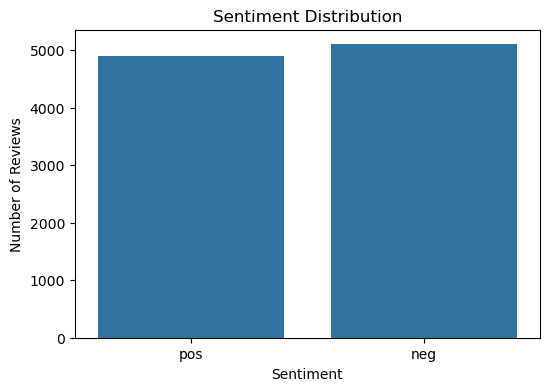

In [15]:
#visualization
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='label')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')

plt.show()

In [16]:
print(df['label'].value_counts(normalize=True) * 100)

label
neg    50.97
pos    49.03
Name: proportion, dtype: float64


In [17]:
#text preprocessing
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [18]:
#create preprocessing fun
def preprocess_text(text):
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # Tokenization
    words = text.split()
    
    # Remove stopwords
    words = [word for word in words if word not in stop_words]
    
    # Lemmatization
    words = [lemmatizer.lemmatize(word) for word in words]
    
    return ' '.join(words)

In [19]:
df['cleaned_review'] = df['review'].apply(preprocess_text)

In [20]:
df[['review', 'cleaned_review']].head()

,review,cleaned_review
0,Stuning even for the non-gamer: This sound tra...,stuning even nongamer sound track beautiful pa...
1,The best soundtrack ever to anything.: I'm rea...,best soundtrack ever anything im reading lot r...
2,Amazing!: This soundtrack is my favorite music...,amazing soundtrack favorite music time hand in...
3,Excellent Soundtrack: I truly like this soundt...,excellent soundtrack truly like soundtrack enj...
4,"Remember, Pull Your Jaw Off The Floor After He...",remember pull jaw floor hearing youve played g...


In [21]:
df.head()

,label,review,cleaned_review
0,pos,Stuning even for the non-gamer: This sound tra...,stuning even nongamer sound track beautiful pa...
1,pos,The best soundtrack ever to anything.: I'm rea...,best soundtrack ever anything im reading lot r...
2,pos,Amazing!: This soundtrack is my favorite music...,amazing soundtrack favorite music time hand in...
3,pos,Excellent Soundtrack: I truly like this soundt...,excellent soundtrack truly like soundtrack enj...
4,pos,"Remember, Pull Your Jaw Off The Floor After He...",remember pull jaw floor hearing youve played g...


In [22]:
print(df['cleaned_review'].isnull().sum())

0


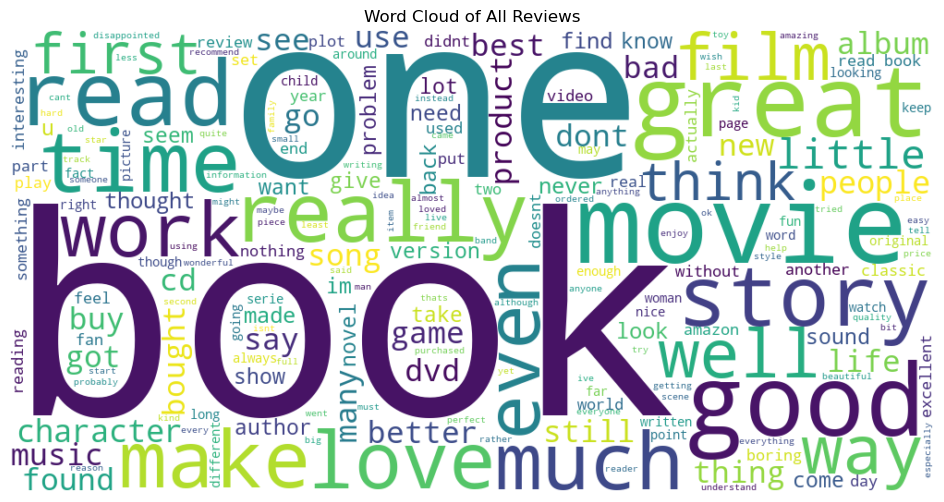

In [23]:
#wordcloud
all_text = ' '.join(df['cleaned_review'])
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(all_text)
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of All Reviews')
plt.show()

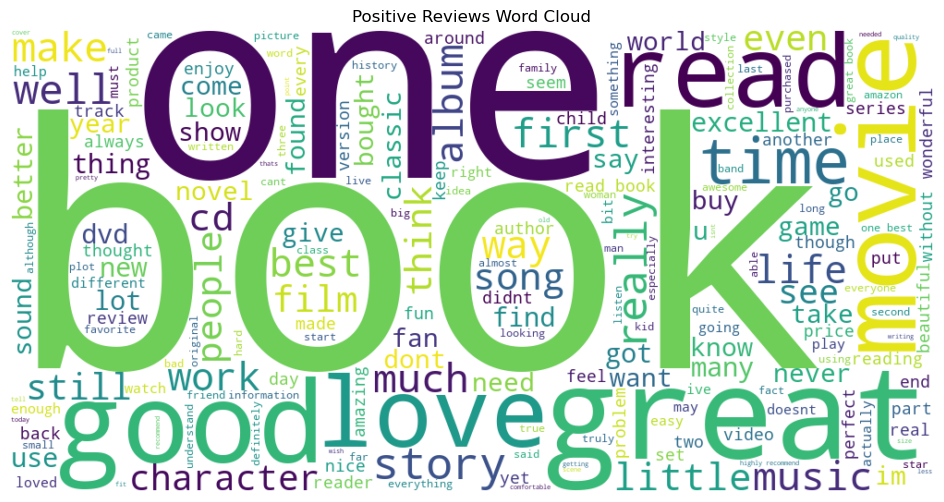

In [24]:
#positive reviews wordcloud
positive_text = ' '.join(
    df[df['label'] == 'pos']['cleaned_review']
)
wordcloud_pos = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(positive_text)
plt.figure(figsize=(12,6))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title('Positive Reviews Word Cloud')
plt.show()

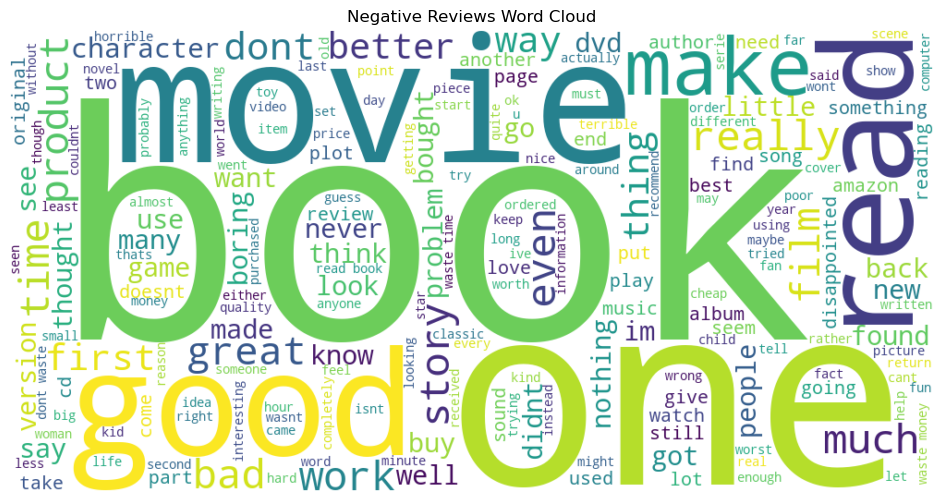

In [25]:
#negative reviews wordcloud
negative_text = ' '.join(
    df[df['label'] == 'neg']['cleaned_review']
)
wordcloud_neg = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(negative_text)
plt.figure(figsize=(12,6))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Negative Reviews Word Cloud')
plt.show()

In [26]:
#find most common words
from collections import Counter
words = ' '.join(df['cleaned_review']).split()
word_counts = Counter(words)
print("Most Common Words:")
print(word_counts.most_common(20))

Most Common Words:
[('book', 7544), ('one', 4055), ('movie', 3027), ('like', 2890), ('read', 2812), ('good', 2774), ('great', 2722), ('time', 2409), ('would', 2381), ('get', 2221), ('dont', 1771), ('story', 1612), ('really', 1605), ('make', 1466), ('first', 1444), ('work', 1440), ('much', 1419), ('even', 1400), ('well', 1372), ('love', 1354)]


In [27]:
positive_words = ' '.join(
    df[df['label'] == 'pos']['cleaned_review']
).split()
positive_counts = Counter(positive_words)
print(positive_counts.most_common(20))

[('book', 3861), ('great', 2089), ('one', 1936), ('good', 1637), ('read', 1574), ('like', 1320), ('movie', 1295), ('time', 1135), ('love', 1036), ('would', 943), ('get', 936), ('well', 857), ('story', 857), ('really', 827), ('best', 801), ('first', 708), ('make', 705), ('work', 679), ('year', 677), ('much', 650)]


In [28]:
negative_words = ' '.join(
    df[df['label'] == 'neg']['cleaned_review']
).split()
negative_counts = Counter(negative_words)
print(negative_counts.most_common(20))

[('book', 3683), ('one', 2119), ('movie', 1732), ('like', 1570), ('would', 1438), ('get', 1285), ('time', 1274), ('dont', 1240), ('read', 1238), ('good', 1137), ('even', 898), ('buy', 821), ('really', 778), ('much', 769), ('make', 761), ('work', 761), ('story', 755), ('bad', 749), ('money', 746), ('first', 736)]


In [29]:
X = df['cleaned_review']
y = df['label']

In [30]:
#convert labels into numbers
y = y.map({
    'neg': 0,
    'pos': 1
})

In [31]:
print(y.value_counts())

label
0    5097
1    4903
Name: count, dtype: int64


In [32]:
#train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 8000
Testing samples: 2000


In [33]:
#TF=IDF
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

In [34]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [35]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (8000, 5000)
Testing TF-IDF shape: (2000, 5000)


In [36]:
#build logistic regrsn
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [37]:
y_pred = model.predict(X_test_tfidf)
print(y_pred[:20])

[0 1 0 1 0 0 0 0 1 1 0 0 0 0 1 1 0 1 0 0]


In [38]:
#accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100)

Accuracy: 0.849
Accuracy Percentage: 84.89999999999999


In [39]:
#f1 scor
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 0.8460754332313966


In [40]:
#classification report
print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=['Negative', 'Positive']
))

Classification Report:
              precision    recall  f1-score   support

    Negative       0.85      0.85      0.85      1019
    Positive       0.85      0.85      0.85       981

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



In [41]:
#confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[868 151]
 [151 830]]


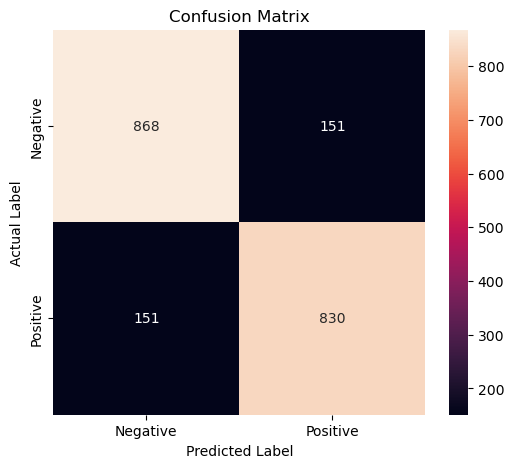

In [42]:
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.show()

In [43]:
#cross validation
cv_scores = cross_val_score(
    model,
    X_train_tfidf,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("Cross-validation scores:")
print(cv_scores)

print("\nMean CV Accuracy:", cv_scores.mean())

Cross-validation scores:
[0.86125  0.855625 0.86875  0.85125  0.855   ]

Mean CV Accuracy: 0.8583749999999999


In [44]:
#new reviews
new_reviews = [
    "This product is excellent and I really love it",
    "This product is terrible and I hate it",
    "Amazing quality and very good product",
    "Worst product I have ever purchased"
]

In [45]:
new_reviews_tfidf = tfidf.transform(new_reviews)

In [46]:
predictions = model.predict(new_reviews_tfidf)

In [47]:
for review, prediction in zip(new_reviews, predictions):
    sentiment = "Positive" if prediction == 1 else "Negative"
    print("Review:", review)
    print("Sentiment:", sentiment)
    print()

Review: This product is excellent and I really love it
Sentiment: Positive

Review: This product is terrible and I hate it
Sentiment: Negative

Review: Amazing quality and very good product
Sentiment: Positive

Review: Worst product I have ever purchased
Sentiment: Negative



In [48]:
#probability prediction
probabilities = model.predict_proba(new_reviews_tfidf)
for review, probability in zip(new_reviews, probabilities):  
    print("Review:", review)
    print("Negative Probability:", probability[0])
    print("Positive Probability:", probability[1])
    print()

Review: This product is excellent and I really love it
Negative Probability: 0.03894932151990971
Positive Probability: 0.9610506784800903

Review: This product is terrible and I hate it
Negative Probability: 0.9465797907480427
Positive Probability: 0.053420209251957396

Review: Amazing quality and very good product
Negative Probability: 0.10883697261833425
Positive Probability: 0.8911630273816658

Review: Worst product I have ever purchased
Negative Probability: 0.940471348528497
Positive Probability: 0.05952865147150295



In [49]:
print("========== MODEL PERFORMANCE ==========")
print("Accuracy :", accuracy)
print("F1 Score :", f1)
print("CV Mean Accuracy :", cv_scores.mean())

========== MODEL PERFORMANCE ==========
Accuracy : 0.849
F1 Score : 0.8460754332313966
CV Mean Accuracy : 0.8583749999999999


**Conclusion:**

The Amazon customer review dataset was successfully analyzed using
Natural Language Processing techniques. The data was cleaned by
removing duplicates, handling missing reviews, converting text to
lowercase, removing punctuation and stopwords, and applying
lemmatization.

TF-IDF was used to convert textual reviews into numerical features.
A Logistic Regression classifier was then trained to classify reviews
as Positive or Negative.

The model was evaluated using accuracy, F1-score, classification
report, confusion matrix, and 5-fold cross-validation.

Overall, the NLP-based sentiment analysis system can automatically
classify customer reviews and can help an e-commerce company identify
positive and negative customer feedback efficiently.
